In [2]:
import os
import numpy as np
import gc
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/My Drive/Teaching/Project/"

FLAIR_dataset = np.load(path + '/FLAIR_dataset.npy')
WMH_masks = np.load(path + '/WMH_masks.npy')

# define function to visualize slices
def show_slices(slices):
   fig, axes = plt.subplots(1, len(slices))
   for i, slice in enumerate(slices):
       axes[i].imshow(slice.T, cmap="gray", origin="lower")

Mounted at /content/drive


(151, 186, 611)
(151, 186, 611)


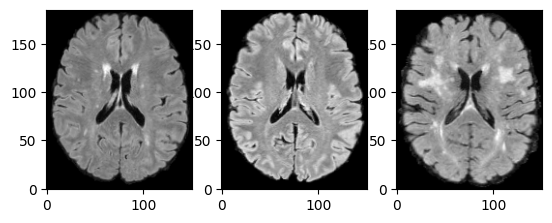

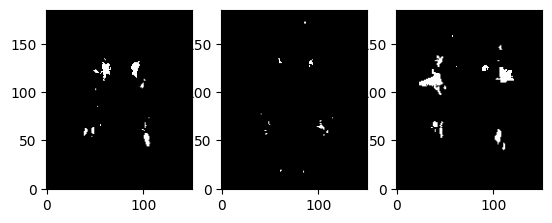

In [3]:
# show the data structures results
subj_0 = FLAIR_dataset[:, :, 0]
subj_1 = FLAIR_dataset[:, :, 1]
subj_2 = FLAIR_dataset[:, :, 2]
show_slices([subj_0, subj_1, subj_2])

mask_0 = WMH_masks[:, :, 0]
mask_1 = WMH_masks[:, :, 1]
mask_2 = WMH_masks[:, :, 2]
show_slices([mask_0, mask_1, mask_2])


print(FLAIR_dataset.shape)
print(WMH_masks.shape)

In [4]:
import numpy as np
from scipy.ndimage import generic_filter
from scipy.stats import skew, kurtosis

def compute_statistics(data, window_size=4):
    pad_width = window_size // 2

    # Define functions to compute mean, std, skewness, and kurtosis
    def window_mean(window):
        return np.mean(window)

    def window_std(window):
        return np.std(window)

    def window_skew(window):
        return skew(window)

    def window_kurtosis(window):
        return kurtosis(window)

    # Pad the dataset to handle borders
    padded_data = np.pad(data, pad_width=pad_width, mode='reflect')

    # Initialize the output arrays
    mean_array = np.zeros_like(data)
    std_array = np.zeros_like(data)
    skew_array = np.zeros_like(data)
    kurtosis_array = np.zeros_like(data)

    # Apply the sliding window for each statistic
    mean_array = generic_filter(padded_data, window_mean, size=window_size)
    std_array = generic_filter(padded_data, window_std, size=window_size)
    skew_array = generic_filter(padded_data, window_skew, size=window_size)
    kurtosis_array = generic_filter(padded_data, window_kurtosis, size=window_size)

    return mean_array[2:-2, 2:-2], std_array[2:-2, 2:-2], skew_array[2:-2, 2:-2], kurtosis_array[2:-2, 2:-2] # remove padded borders

# Initialize result arrays
mean_dataset = np.zeros_like(FLAIR_dataset)
std_dataset = np.zeros_like(FLAIR_dataset)
skew_dataset = np.zeros_like(FLAIR_dataset)
kurtosis_dataset = np.zeros_like(FLAIR_dataset)

# Compute statistics for each image
for i in range(FLAIR_dataset.shape[-1]):
    print(i)
    mean_dataset[..., i], std_dataset[..., i], skew_dataset[..., i], kurtosis_dataset[..., i] = compute_statistics(FLAIR_dataset[..., i])


0


SystemError: _PyEval_EvalFrameDefault returned a result with an exception set

In [ ]:
# np.save(path + '/mean_dataset', mean_dataset)
# np.save(path + '/std_dataset', std_dataset)
# np.save(path + '/skew_dataset', skew_dataset)
# np.save(path + '/kurtosis_dataset', kurtosis_dataset)

In [ ]:
mean_dataset = np.load(path + '/mean_dataset.npy')
std_dataset = np.load(path + '/std_dataset.npy')
skew_dataset = np.load(path + '/skew_dataset.npy')
kurtosis_dataset = np.load(path + '/kurtosis_dataset.npy')

# show the data structures results
slice_0 = mean_dataset[:, :, 0]
slice_1 = mean_dataset[:, :, 1]
slice_2 = mean_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])

slice_0 = std_dataset[:, :, 0]
slice_1 = std_dataset[:, :, 1]
slice_2 = std_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])

# show the data structures results
slice_0 = skew_dataset[:, :, 0]
slice_1 = skew_dataset[:, :, 1]
slice_2 = skew_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])

slice_0 = kurtosis_dataset[:, :, 0]
slice_1 = kurtosis_dataset[:, :, 1]
slice_2 = kurtosis_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])


-1.7285059272230405
11.066666666666668


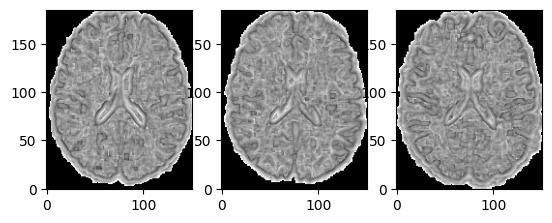

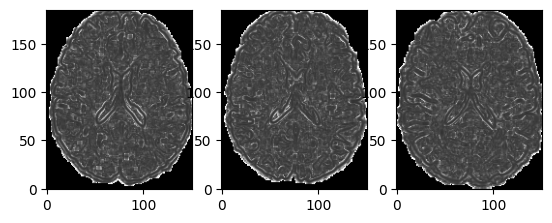

In [ ]:
# some feature computation generates nans that can create issues during the training
# replace nans value with -5
skew_dataset = np.nan_to_num(skew_dataset, nan=-5)

# show the data structures results
slice_0 = skew_dataset[:, :, 0]
slice_1 = skew_dataset[:, :, 1]
slice_2 = skew_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])

kurtosis_dataset = np.nan_to_num(kurtosis_dataset, nan=-5)
# show the data structures results
slice_0 = kurtosis_dataset[:, :, 0]
slice_1 = kurtosis_dataset[:, :, 1]
slice_2 = kurtosis_dataset[:, :, 2]
show_slices([slice_0, slice_1, slice_2])